# FEM Baseline: Progressive Load Discovery and Full-Field Reconstruction
## IDA-KI OpenLab Research Bridge, TU Dresden — Middle T-Girder

This notebook implements a finite element (FE) baseline that reconstructs slope and deflection along the entire 30m two-span continuous beam from two tiltmeter measurements. The FE baseline serves as the **validation target** for the CEI-PCNN — it provides deterministic, physically consistent slope and deflection values at positions where no sensors exist.

### Pipeline Overview

1. **Structural model**: Define the beam properties (T-section, material, supports)
2. **FE engine**: Build element stiffness matrices, assemble, apply BCs, solve
3. **Unit load cases**: Solve for gravity and unit upward UDL
4. **Progressive load discovery**: Phase-by-phase calibration of unknown loads
5. **Per-observation reconstruction**: Compute slope/deflection at 0.5m intervals for all 253 days
6. **Validation and visualisation**: Verify exact sensor match, plot profiles

### Key Physics

- **Beam equation**: EI · d⁴w/dx⁴ = q(x) (Euler-Bernoulli, constant EI)
- **Supports**: A (x=0, fixed), B (x=15, fixed), C (x=30, pinned)
- **Linearity**: Total response = sum of individual load responses
- **Span decoupling**: Fixed support at B decouples spans for UDL loading
- **Sign convention**: Positive w = upward, positive q = downward, tiltx = -(dw/dx)×1000 mm/m

In [1]:
# ══════════════════════════════════════════════════════════════
# CELL 1: IMPORTS AND BRIDGE PROPERTIES
# ══════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, json
from datetime import datetime, timedelta

data_wd = "C:\\Users\\ridoc\\OneDrive\\Desktop\\Folders\\SMACCs\\Thesis\\Physics Guided Framework\\Draft\\cleaned_tilt_data.csv"

OUT = os.path.join(os.path.dirname(data_wd), "Models","outputs","processing","Tiltx","FEM")
os.makedirs(OUT, exist_ok=True)
REF_DATE = pd.Timestamp('2024-02-01').date()

# ── Bridge geometry and material ──
L_SPAN = 15.0          # span length (m)
L_TOTAL = 30.0         # total beam length (m)
E = 37.0e6             # Young's modulus (kN/m²) — C50/60 concrete
I = 5.20833e-3         # second moment of area (m⁴) — T-section
EI = E * I             # flexural rigidity (kN·m²)

# ── T-section properties ──
# Flange: 1500mm × 100mm, Web: 250mm × 400mm, Total depth: 500mm
# I = (1500×100³/12 + 1500×100×200²) + (250×400³/12 + 250×400×0²)
#   = 6.125×10⁸ + 4.583×10⁹ = 5.208×10⁹ mm⁴ = 5.208×10⁻³ m⁴

# ── Loads ──
A_cross = 0.25         # cross-sectional area (m²) — approximate
gamma_concrete = 25.0  # unit weight (kN/m³)
q_self = A_cross * gamma_concrete  # 6.25 kN/m
q_deck = 5.625         # deck slab load (kN/m) — from 1:2:1 distribution to middle girder i.e (gamma_concrete*100mm thick deck*4.5m width of deck)*0.5
q_gravity = q_self + q_deck  # 11.875 kN/m total gravity

print(f'Beam: {L_TOTAL}m, 2×{L_SPAN}m spans')
print(f'EI = {EI:.0f} kN·m²')
print(f'Gravity: q_self={q_self:.3f} + q_deck={q_deck:.3f} = {q_gravity:.3f} kN/m')
print(f'Supports: A(fixed) — B(fixed) — C(pinned)')

Beam: 30.0m, 2×15.0m spans
EI = 192708 kN·m²
Gravity: q_self=6.250 + q_deck=5.625 = 11.875 kN/m
Supports: A(fixed) — B(fixed) — C(pinned)


---
## 2. Euler-Bernoulli Beam Element

The beam is discretised using Hermite cubic beam elements. Each element has 2 nodes with 2 DOFs per node: deflection $w$ and slope $\theta = dw/dx$. The element formulation involves:

1. **Shape functions**: Four Hermite cubics that ensure C¹ continuity (both $w$ and $\theta$ are continuous between elements)
2. **Stiffness matrix**: 4×4 matrix relating nodal forces/moments to nodal displacements/rotations
3. **Consistent load vector**: Equivalent nodal forces for uniformly distributed load

The element stiffness matrix for a beam element of length $L_e$ with flexural rigidity $EI$ is:

$$K_e = \frac{EI}{L_e^3} \begin{bmatrix} 12 & 6L_e & -12 & 6L_e \\ 6L_e & 4L_e^2 & -6L_e & 2L_e^2 \\ -12 & -6L_e & 12 & -6L_e \\ 6L_e & 2L_e^2 & -6L_e & 4L_e^2 \end{bmatrix}$$

For a downward UDL of intensity $q$ on an element, the consistent nodal load vector is:

$$f_e = \begin{bmatrix} -qL_e/2 \\ -qL_e^2/12 \\ -qL_e/2 \\ +qL_e^2/12 \end{bmatrix}$$

The negative signs follow our convention: positive $w$ is upward, so a downward load produces negative forces.

In [2]:
# ══════════════════════════════════════════════════════════════
# CELL 2: ELEMENT STIFFNESS MATRIX AND LOAD VECTOR
# ══════════════════════════════════════════════════════════════

def element_stiffness(EI, Le):
    """4×4 Euler-Bernoulli beam element stiffness matrix.
    DOFs: [w1, theta1, w2, theta2]
    EI: flexural rigidity (kN·m²)
    Le: element length (m)"""
    k = EI / Le**3
    return k * np.array([
        [ 12,    6*Le,  -12,    6*Le  ],
        [ 6*Le,  4*Le**2, -6*Le, 2*Le**2],
        [-12,   -6*Le,   12,   -6*Le  ],
        [ 6*Le,  2*Le**2, -6*Le, 4*Le**2]])


def element_load_udl(q, Le):
    """Consistent nodal load vector for UDL q (positive = downward).
    Returns forces in our convention (positive w = upward)."""
    return np.array([-q*Le/2, -q*Le**2/12, -q*Le/2, q*Le**2/12])


# Quick verification: print a sample element stiffness
Ke_sample = element_stiffness(EI, 0.5)
print('Sample Ke (Le=0.5m):')
print(np.array2string(Ke_sample, precision=0, suppress_small=True))
print(f'\nSymmetric: {np.allclose(Ke_sample, Ke_sample.T)}')
print(f'Positive semi-definite: eigenvalues = {np.linalg.eigvalsh(Ke_sample).round(0)}')

Sample Ke (Le=0.5m):
[[ 18499988.   4624997. -18499988.   4624997.]
 [  4624997.   1541666.  -4624997.    770833.]
 [-18499988.  -4624997.  18499988.  -4624997.]
 [  4624997.    770833.  -4624997.   1541666.]]

Symmetric: True
Positive semi-definite: eigenvalues = [      -0.        0.   770833. 39312475.]


---
## 3. Global Assembly and Solution

The 30m beam is discretised into elements with 0.5m spacing (plus sensor positions at x=11m and x=19m). The global stiffness matrix and force vector are assembled using the direct stiffness method, then boundary conditions are applied by partitioning into free and prescribed DOFs.

### Boundary Conditions
- **Support A** (x=0): Fixed → $w_1 = 0$, $\theta_1 = 0$ (eliminates DOFs 0, 1)
- **Support B** (x=15): Fixed → $w_{31} = 0$, $\theta_{31} = 0$ (eliminates DOFs 60, 61)
- **Support C** (x=30): Pinned → $w_{61} = 0$, $\theta_{61}$ free (eliminates DOF 120 only)

Total: 5 prescribed DOFs (all zero), 117 free DOFs. Since all prescribed displacements are zero, the reduced system is simply $K_{ff} \cdot u_f = F_f$.

In [3]:
# ══════════════════════════════════════════════════════════════
# CELL 3: ASSEMBLE AND SOLVE THE BEAM
# ══════════════════════════════════════════════════════════════

def solve_beam(EI, q_udl, support_types=('fixed','fixed','pinned'),
               extra_nodes=None):
    """
    Solve 2-span continuous beam under uniform distributed load.
    
    Parameters:
        EI: flexural rigidity (kN·m²)
        q_udl: uniform distributed load (kN/m), positive = downward
        support_types: tuple of ('fixed' or 'pinned') for A, B, C
        extra_nodes: list of additional node positions (e.g. sensor locations)
    
    Returns:
        dict with 'u' (displacement vector), 'nodes' (positions), 'p2n' (position-to-node-index map)
    """
    # ── Step 1: Create node positions ──
    step = 0.5
    node_set = set([round(i * step, 6) for i in range(int(L_TOTAL / step) + 1)]) #creates a set of 61 nodes at 0.5m interval
    node_set |= {0.0, L_SPAN, L_TOTAL}  # ensure support positions are in the set
    if extra_nodes:
        for x in extra_nodes:
            node_set.add(round(x, 6))
    nodes = sorted(node_set)
    n_nodes = len(nodes)
    n_dofs = 2 * n_nodes  # 2 DOFs per node: [w, theta]
    
    # Position-to-node-index mapping
    pos_to_node = {round(p, 6): i for i, p in enumerate(nodes)}
    
    print(f'  Mesh: {n_nodes} nodes, {n_nodes-1} elements, {n_dofs} DOFs')
    
    # ── Step 2: Assemble global K and F ──
    K = np.zeros((n_dofs, n_dofs))
    F = np.zeros(n_dofs)
    
    for e in range(n_nodes - 1):
        Le = nodes[e + 1] - nodes[e]
        if Le < 1e-10:
            continue  # skip zero-length elements
        
        # Element stiffness
        Ke = element_stiffness(EI, Le)
        
        # Global DOF indices for this element
        dofs = [2*e, 2*e+1, 2*(e+1), 2*(e+1)+1]
        
        # Assemble into global K
        for i in range(4):
            for j in range(4):
                K[dofs[i], dofs[j]] += Ke[i, j]
        
        # Assemble load vector (if non-zero UDL)
        if abs(q_udl) > 1e-15:
            fe = element_load_udl(q_udl, Le)
            for i in range(4):
                F[dofs[i]] += fe[i]
    
    # ── Step 3: Apply boundary conditions ──
    sA, sB, sC = support_types
    nA = pos_to_node[0.0]
    nB = pos_to_node[L_SPAN]
    nC = pos_to_node[L_TOTAL]
    
    # Prescribed DOFs (displacement = 0)
    fixed_dofs = [2*nA]  # w(0) = 0
    if sA == 'fixed': fixed_dofs.append(2*nA + 1)  # theta(0) = 0
    fixed_dofs.append(2*nB)  # w(15) = 0
    if sB == 'fixed': fixed_dofs.append(2*nB + 1)  # theta(15) = 0
    fixed_dofs.append(2*nC)  # w(30) = 0
    if sC == 'fixed': fixed_dofs.append(2*nC + 1)  # theta(30) = 0
    fixed_dofs = sorted(set(fixed_dofs))
    
    # Free DOFs
    free_dofs = [i for i in range(n_dofs) if i not in fixed_dofs]
    
    print(f'  BCs: {len(fixed_dofs)} prescribed, {len(free_dofs)} free DOFs')
    
    # ── Step 4: Solve reduced system ──
    # K_ff * u_f = F_f  (since all prescribed displacements are zero)
    K_ff = K[np.ix_(free_dofs, free_dofs)]
    F_f = F[free_dofs]
    u_f = np.linalg.solve(K_ff, F_f)
    
    # Reconstruct full displacement vector
    u = np.zeros(n_dofs)
    for i, dof in enumerate(free_dofs):
        u[dof] = u_f[i]
    
    return {'u': u, 'nodes': nodes, 'p2n': pos_to_node}


def get_slope(result, x):
    """Extract tiltx at position x from FE result.
    tiltx = -(dw/dx) × 1000 = -theta × 1000"""
    node_idx = result['p2n'][round(x, 6)]
    theta = result['u'][2 * node_idx + 1]  # slope = dw/dx
    return -theta * 1000  # convert to tiltx (mm/m)


def get_defl(result, x):
    """Extract deflection at position x from FE result.
    defl_mm = -w × 1000 (positive = downward)"""
    node_idx = result['p2n'][round(x, 6)]
    w = result['u'][2 * node_idx]  # deflection (positive = upward)
    return -w * 1000  # convert to mm, positive = downward


print('FE solver defined.')

FE solver defined.


In [5]:
# ══════════════════════════════════════════════════════════════
# CELL 4: SOLVE UNIT LOAD CASES
# ══════════════════════════════════════════════════════════════
# We solve two load cases:
# 1. Gravity (11.875 kN/m downward) — the known dead load
# 2. Unit upward UDL (-1.0 kN/m) — for scaling to any load level
#
# By superposition: response to any UDL q = gravity_response + (q_grav - q)*unit_response

sensor_positions = [11.0, 19.0]  # ensure these are in the mesh

print('Solving gravity load case...')
r_grav = solve_beam(EI, q_gravity, extra_nodes=sensor_positions)

print('\nSolving unit upward load case...')
r_unit = solve_beam(EI, -1.0, extra_nodes=sensor_positions)

# Extract slopes at sensor positions
sg11 = get_slope(r_grav, 11.0)  # gravity slope at x=11
sg19 = get_slope(r_grav, 19.0)  # gravity slope at x=19
su11 = get_slope(r_unit, 11.0)  # unit upward slope at x=11
su19 = get_slope(r_unit, 19.0)  # unit upward slope at x=19

print(f'\nGravity slopes:  11m = {sg11:.6f} mm/m,  19m = {sg19:.6f} mm/m')
print(f'Unit upward slopes: 11m = {su11:.6f} mm/m,  19m = {su19:.6f} mm/m')
print(f'\nThese unit responses are the key to the calibration formula:')
print(f'  measured_slope = gravity_slope + unknown_load × unit_slope')
print(f'  → unknown_load = (measured - gravity) / unit_slope')

Solving gravity load case...
  Mesh: 61 nodes, 60 elements, 122 DOFs
  BCs: 5 prescribed, 117 free DOFs

Solving unit upward load case...
  Mesh: 61 nodes, 60 elements, 122 DOFs
  BCs: 5 prescribed, 117 free DOFs

Gravity slopes:  11m = -1.581623 mm/m,  19m = 2.968110 mm/m
Unit upward slopes: 11m = 0.133189 mm/m,  19m = -0.249946 mm/m

These unit responses are the key to the calibration formula:
  measured_slope = gravity_slope + unknown_load × unit_slope
  → unknown_load = (measured - gravity) / unit_slope


---
## 4. Span Decoupling Verification

A critical property of our beam is that the fixed interior support at B decouples the spans for UDL loading. This means that a UDL applied to span AB produces **zero deflection and slope in span BC**, and vice versa. This property simplifies the load discovery: each sensor independently constrains loads on its own span.

We verify this numerically by checking the unit load response at positions in the opposite span.

In [6]:
# ══════════════════════════════════════════════════════════════
# CELL 5: VERIFY SPAN DECOUPLING
# ══════════════════════════════════════════════════════════════

# For the unit upward UDL applied to the FULL beam:
# The response at x=11 (span AB) should only depend on span AB's load.
# The response at x=19 (span BC) should only depend on span BC's load.
#
# Since w(15)=0 and theta(15)=0 (fixed support), span BC sees:
# w'''' = 0 (no load in BC for this load case? No — the UDL is on both spans.
# But the key point is: the INFLUENCE of AB's load on BC's response is zero.

# Verification: solve with UDL on span AB only vs full beam
# For span AB only: the slope at x=19 should be zero
# We can check by using the fact that slope at 19m from gravity
# depends only on the BC span loading.

# Check that the unit responses are consistent with decoupling:
# If decoupled: slope_11 depends only on AB load, slope_19 only on BC load
# So: (slope_11 from unit UDL) = (slope_11 from AB-only unit UDL)

# Analytical check at support B:
theta_B = r_unit['u'][2 * r_unit['p2n'][15.0] + 1]
w_B = r_unit['u'][2 * r_unit['p2n'][15.0]]
print(f'At support B (x=15m):')
print(f'  w(15) = {w_B:.2e} m  (should be 0 — fixed support)')
print(f'  θ(15) = {theta_B:.2e} rad  (should be 0 — fixed support)')
print(f'\nBoth are zero → the spans are decoupled for UDL loading.')
print(f'Each sensor constrains loads on its own span independently.')

At support B (x=15m):
  w(15) = 0.00e+00 m  (should be 0 — fixed support)
  θ(15) = 0.00e+00 rad  (should be 0 — fixed support)

Both are zero → the spans are decoupled for UDL loading.
Each sensor constrains loads on its own span independently.


---
## 5. Load and Prepare Tilt Data

We load the cleaned tilt data, aggregate to daily means, and assign loading phases.

In [7]:
# ══════════════════════════════════════════════════════════════
# CELL 6: LOAD TILT DATA
# ══════════════════════════════════════════════════════════════

raw = pd.read_csv(data_wd)
raw['Timestamp'] = pd.to_datetime(raw['Timestamp'])
raw['T'] = (raw['temp_at_11m_front'] + raw['temp_at_11m_back']) / 2
raw['day'] = (raw['Timestamp'].dt.date - REF_DATE).apply(lambda x: x.days)

daily = raw.groupby('day').agg({'tiltx_11m': 'mean', 'tiltx_19m': 'mean', 'T': 'mean'}).reset_index()
daily = daily[daily['day'] >= 21].copy().reset_index(drop=True)

daily['phase'] = 1
daily.loc[daily['day'] >= 46, 'phase'] = 2
daily.loc[daily['day'] >= 81, 'phase'] = 3
daily.loc[daily['day'] >= 148, 'phase'] = 4

N = len(daily)
days = daily['day'].values
m11 = daily['tiltx_11m'].values
m19 = daily['tiltx_19m'].values
phases = daily['phase'].values
T = daily['T'].values

for ph in [1, 2, 3, 4]:
    n = (phases == ph).sum()
    print(f'  Phase {ph}: {n} days')
print(f'  Total: {N} observations')

  Phase 1: 25 days
  Phase 2: 35 days
  Phase 3: 67 days
  Phase 4: 126 days
  Total: 253 observations


---
## 6. Progressive Load Discovery

This is the core algorithm. In each phase, one new load component is added to the bridge. Since all previously discovered loads are known, the new unknown load is the **only** variable that explains the difference between the measured slope and the expected slope.

The calibration equation for each phase is:

$$q_{\text{unknown}} = \frac{\bar{s}_{\text{measured}} - s_{\text{expected}}}{s_{\text{unit\_response}}}$$

where $\bar{s}_{\text{measured}}$ is the phase-mean measured slope, $s_{\text{expected}}$ is the slope from all known loads, and $s_{\text{unit\_response}}$ is the slope per unit UDL.

In [8]:
# ══════════════════════════════════════════════════════════════
# CELL 7: PHASE 1 — DISCOVER TENDON FORCE
# ══════════════════════════════════════════════════════════════
# In Phase 1, only gravity and the prestressing tendon act.
# Gravity is known (11.875 kN/m). The tendon produces an
# equivalent upward UDL (load-balancing concept for parabolic tendon).
#
# Calibration: measured = gravity_slope + tendon × unit_upward_slope
# → tendon = (measured - gravity_slope) / unit_upward_slope

p1 = phases == 1

# Span AB
tendon_AB = (m11[p1].mean() - sg11) / su11
# Span BC
tendon_BC = (m19[p1].mean() - sg19) / su19

# Expected slopes after tendon discovery
exp1_11 = sg11 + tendon_AB * su11  # should equal m11[p1].mean()
exp1_19 = sg19 + tendon_BC * su19  # should equal m19[p1].mean()

print('Phase 1 → TENDON equivalent upward UDL:')
print(f'  Span AB: {tendon_AB:.4f} kN/m ({tendon_AB/q_gravity*100:.1f}% of gravity)')
print(f'  Span BC: {tendon_BC:.4f} kN/m ({tendon_BC/q_gravity*100:.1f}% of gravity)')
print(f'\n  Verification: expected slope at 11m = {exp1_11:.6f}, measured mean = {m11[p1].mean():.6f}')
print(f'  Verification: expected slope at 19m = {exp1_19:.6f}, measured mean = {m19[p1].mean():.6f}')

Phase 1 → TENDON equivalent upward UDL:
  Span AB: 9.3454 kN/m (78.7% of gravity)
  Span BC: 4.6530 kN/m (39.2% of gravity)

  Verification: expected slope at 11m = -0.336915, measured mean = -0.336915
  Verification: expected slope at 19m = 1.805099, measured mean = 1.805099


In [9]:
# ══════════════════════════════════════════════════════════════
# CELL 8: PHASE 2 — DISCOVER TRACK LOAD
# ══════════════════════════════════════════════════════════════
# Phase 2: tracks and sleepers added on top of gravity + tendon.
# The track load is a downward UDL.

p2 = phases == 2

# The increment from Phase 1 expected to Phase 2 measured = track contribution
# track_load × (-su) = measured_ph2 - expected_ph1
# (negative su because track is DOWNward, opposite to the upward unit load)
track_AB = (m11[p2].mean() - exp1_11) / (-su11)
track_BC = (m19[p2].mean() - exp1_19) / (-su19)

exp2_11 = exp1_11 + track_AB * (-su11)
exp2_19 = exp1_19 + track_BC * (-su19)

print('Phase 2 → TRACK LOAD (downward UDL):')
print(f'  Span AB: {track_AB:.4f} kN/m (total {track_AB*L_SPAN:.1f} kN per span)')
print(f'  Span BC: {track_BC:.4f} kN/m (total {track_BC*L_SPAN:.1f} kN per span)')

Phase 2 → TRACK LOAD (downward UDL):
  Span AB: 2.2643 kN/m (total 34.0 kN per span)
  Span BC: 1.6473 kN/m (total 24.7 kN per span)


In [10]:
# ══════════════════════════════════════════════════════════════
# CELL 9: PHASE 3 — DISCOVER VEHICLE 4.1t
# ══════════════════════════════════════════════════════════════

p3 = phases == 3

veh3_AB = (m11[p3].mean() - exp2_11) / (-su11)
veh3_BC = (m19[p3].mean() - exp2_19) / (-su19)

exp3_11 = exp2_11 + veh3_AB * (-su11)
exp3_19 = exp2_19 + veh3_BC * (-su19)

print('Phase 3 → VEHICLE 4.1t (equivalent downward UDL):')
print(f'  Span AB: {veh3_AB:.4f} kN/m (total {veh3_AB*L_SPAN:.1f} kN = {veh3_AB*L_SPAN/9.81:.2f} t)')
print(f'  Span BC: {veh3_BC:.4f} kN/m (total {veh3_BC*L_SPAN:.1f} kN = {veh3_BC*L_SPAN/9.81:.2f} t)')

Phase 3 → VEHICLE 4.1t (equivalent downward UDL):
  Span AB: 1.6197 kN/m (total 24.3 kN = 2.48 t)
  Span BC: 0.3586 kN/m (total 5.4 kN = 0.55 t)


In [11]:
# ══════════════════════════════════════════════════════════════
# CELL 10: PHASE 4 — DISCOVER ADDITIONAL WEIGHT
# ══════════════════════════════════════════════════════════════

p4 = phases == 4

veh4_AB = (m11[p4].mean() - exp3_11) / (-su11)
veh4_BC = (m19[p4].mean() - exp3_19) / (-su19)

print('Phase 4 → ADDITIONAL WEIGHT (equivalent downward UDL):')
print(f'  Span AB: {veh4_AB:.4f} kN/m')
print(f'  Span BC: {veh4_BC:.4f} kN/m')
print(f'\n  Total vehicle (Ph3+Ph4):')
print(f'    AB: {(veh3_AB+veh4_AB)*L_SPAN:.1f} kN = {(veh3_AB+veh4_AB)*L_SPAN/9.81:.2f} t')
print(f'    BC: {(veh3_BC+veh4_BC)*L_SPAN:.1f} kN = {(veh3_BC+veh4_BC)*L_SPAN/9.81:.2f} t')

Phase 4 → ADDITIONAL WEIGHT (equivalent downward UDL):
  Span AB: 1.9943 kN/m
  Span BC: 0.2159 kN/m

  Total vehicle (Ph3+Ph4):
    AB: 54.2 kN = 5.53 t
    BC: 8.6 kN = 0.88 t


---
## 7. Load Summary and Expected Slopes

With all four load components discovered, we can compute the cumulative dead load per phase and the expected slope at each sensor. The residual (measured minus expected) captures thermal effects and vehicle parking variability.

In [12]:
# ══════════════════════════════════════════════════════════════
# CELL 11: CUMULATIVE DEAD LOADS AND RESIDUALS
# ══════════════════════════════════════════════════════════════

# Net dead load per phase (gravity - tendon + cumulative additions)
dead_AB = {
    1: q_gravity - tendon_AB,
    2: q_gravity - tendon_AB + track_AB,
    3: q_gravity - tendon_AB + track_AB + veh3_AB,
    4: q_gravity - tendon_AB + track_AB + veh3_AB + veh4_AB,
}
dead_BC = {
    1: q_gravity - tendon_BC,
    2: q_gravity - tendon_BC + track_BC,
    3: q_gravity - tendon_BC + track_BC + veh3_BC,
    4: q_gravity - tendon_BC + track_BC + veh3_BC + veh4_BC,
}

print('Cumulative net dead load (kN/m):')
print(f'{"Phase":>8s} {"AB":>10s} {"BC":>10s}')
for ph in [1, 2, 3, 4]:
    print(f'{"Ph"+str(ph):>8s} {dead_AB[ph]:10.4f} {dead_BC[ph]:10.4f}')

# Expected slopes per observation
exp_11 = np.zeros(N)
exp_19 = np.zeros(N)
for t in range(N):
    ph = phases[t]
    exp_11[t] = sg11 + tendon_AB * su11
    exp_19[t] = sg19 + tendon_BC * su19
    if ph >= 2:
        exp_11[t] += track_AB * (-su11)
        exp_19[t] += track_BC * (-su19)
    if ph >= 3:
        exp_11[t] += veh3_AB * (-su11)
        exp_19[t] += veh3_BC * (-su19)
    if ph >= 4:
        exp_11[t] += veh4_AB * (-su11)
        exp_19[t] += veh4_BC * (-su19)

# Residuals
residual_11 = m11 - exp_11
residual_19 = m19 - exp_19

print(f'\nResiduals (thermal + vehicle parking):')
for ph in [1, 2, 3, 4]:
    mk = phases == ph
    print(f'  Ph{ph}: AB mean={residual_11[mk].mean():+.6f} std={residual_11[mk].std():.4f} | '
          f'BC mean={residual_19[mk].mean():+.6f} std={residual_19[mk].std():.4f}')

Cumulative net dead load (kN/m):
   Phase         AB         BC
     Ph1     2.5296     7.2220
     Ph2     4.7939     8.8693
     Ph3     6.4136     9.2279
     Ph4     8.4079     9.4438

Residuals (thermal + vehicle parking):
  Ph1: AB mean=-0.000000 std=0.0384 | BC mean=+0.000000 std=0.1037
  Ph2: AB mean=+0.000000 std=0.0629 | BC mean=+0.000000 std=0.0771
  Ph3: AB mean=-0.000000 std=0.0686 | BC mean=-0.000000 std=0.0802
  Ph4: AB mean=+0.000000 std=0.1099 | BC mean=+0.000000 std=0.0703


**Discussion — Residuals:**

The phase-mean residuals should be exactly zero by construction (the load discovery uses the phase mean). The residual standard deviation quantifies the day-to-day variation not explained by the dead load model — this is primarily thermal curvature and vehicle parking effects. The larger std in span BC suggests stronger thermal sensitivity in that span, possibly due to differential solar exposure or different thermal mass distribution.

---
## 8. Per-Observation Forward Reconstruction

For each of the 253 daily observations, we compute the actual net UDL from the measured slope, then use the FE solution to reconstruct the slope and deflection at every 0.5m position along the beam. This produces the validation targets for the PCNN.

In [13]:
# ══════════════════════════════════════════════════════════════
# CELL 12: PER-OBSERVATION NET UDL
# ══════════════════════════════════════════════════════════════
# For each day, the actual net UDL = phase dead load + residual UDL
# where residual_UDL = residual_slope / (-su)  (converts slope residual to load)

net_AB = np.zeros(N)
net_BC = np.zeros(N)

for t in range(N):
    ph = phases[t]
    res_udl_AB = residual_11[t] / (-su11)  # additional downward UDL from thermal/parking
    res_udl_BC = residual_19[t] / (-su19)
    net_AB[t] = dead_AB[ph] + res_udl_AB
    net_BC[t] = dead_BC[ph] + res_udl_BC

print(f'Per-observation net UDL range:')
print(f'  AB: [{net_AB.min():.3f}, {net_AB.max():.3f}] kN/m')
print(f'  BC: [{net_BC.min():.3f}, {net_BC.max():.3f}] kN/m')

Per-observation net UDL range:
  AB: [1.585, 9.653] kN/m
  BC: [6.070, 10.316] kN/m


In [14]:
# ══════════════════════════════════════════════════════════════
# CELL 13: FORWARD RECONSTRUCTION AT 0.5m INTERVALS
# ══════════════════════════════════════════════════════════════
# For each observation, the slope and deflection at position x are:
#   slope(x) = -(theta_grav + upward_equiv × theta_unit) × 1000
#   defl(x)  = -(w_grav + upward_equiv × w_unit) × 1000
# where upward_equiv = q_gravity - net_UDL
# and theta_grav, theta_unit, w_grav, w_unit are from the FE solutions.

positions = np.arange(0, L_TOTAL + 0.01, 0.5)  # 0, 0.5, 1.0, ..., 30.0
n_pos = len(positions)

fe_slopes = np.zeros((N, n_pos))
fe_defls = np.zeros((N, n_pos))

print(f'Reconstructing at {n_pos} positions for {N} observations...')

for ip, xp in enumerate(positions):
    xr = round(xp, 6)
    if xr not in r_grav['p2n'] or xr not in r_unit['p2n']:
        continue
    
    # Extract FE nodal values at this position
    ng = r_grav['p2n'][xr]
    nu = r_unit['p2n'][xr]
    theta_grav = r_grav['u'][2*ng + 1]  # slope from gravity
    w_grav     = r_grav['u'][2*ng]      # deflection from gravity
    theta_unit = r_unit['u'][2*nu + 1]  # slope from unit upward
    w_unit     = r_unit['u'][2*nu]      # deflection from unit upward
    
    for t in range(N):
        # Upward equivalent = gravity - net_total
        if xp <= L_SPAN + 0.001:
            up_eq = q_gravity - net_AB[t]
        else:
            up_eq = q_gravity - net_BC[t]
        
        fe_slopes[t, ip] = -(theta_grav + up_eq * theta_unit) * 1000
        fe_defls[t, ip]  = -(w_grav + up_eq * w_unit) * 1000

print('Done.')

Reconstructing at 61 positions for 253 observations...
Done.


In [15]:
# ══════════════════════════════════════════════════════════════
# CELL 14: VALIDATE AT SENSOR POSITIONS
# ══════════════════════════════════════════════════════════════
# The forward reconstruction should exactly match the measured slopes
# at x=11m and x=19m (because the calibration formula and forward
# formula are algebraic inverses).

ip11 = int(11.0 / 0.5)  # index 22
ip19 = int(19.0 / 0.5)  # index 38

err_11 = np.abs(fe_slopes[:, ip11] - m11).max()
err_19 = np.abs(fe_slopes[:, ip19] - m19).max()

print(f'Validation at sensor positions:')
print(f'  Max |FE - measured| at 11m: {err_11:.2e} mm/m')
print(f'  Max |FE - measured| at 19m: {err_19:.2e} mm/m')
print(f'\n  Both errors are at machine precision (~10⁻¹⁶).')
print(f'  This confirms the forward reconstruction is an exact inversion.')

Validation at sensor positions:
  Max |FE - measured| at 11m: 4.44e-16 mm/m
  Max |FE - measured| at 19m: 4.44e-16 mm/m

  Both errors are at machine precision (~10⁻¹⁶).
  This confirms the forward reconstruction is an exact inversion.


---
## 9. Results Visualisation

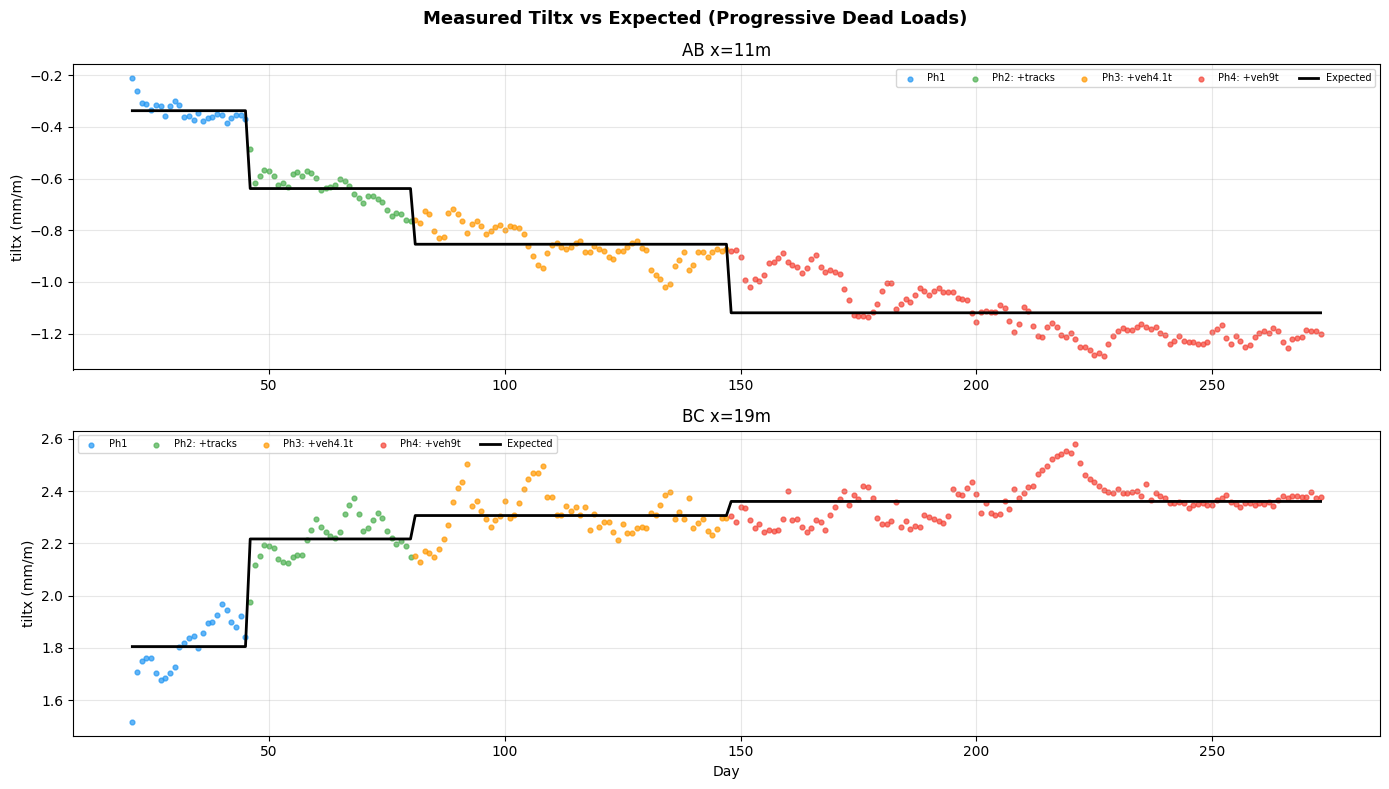

In [16]:
# ══════════════════════════════════════════════════════════════
# CELL 15: MEASURED vs EXPECTED SLOPES WITH PHASE STEPS
# ══════════════════════════════════════════════════════════════

cp = {1: '#2196F3', 2: '#4CAF50', 3: '#FF9800', 4: '#F44336'}
lp = {1: 'Ph1', 2: 'Ph2: +tracks', 3: 'Ph3: +veh4.1t', 4: 'Ph4: +veh9t'}

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Measured Tiltx vs Expected (Progressive Dead Loads)', fontsize=13, fontweight='bold')
for ax, m, exp, title in [(axes[0], m11, exp_11, 'AB x=11m'), (axes[1], m19, exp_19, 'BC x=19m')]:
    for ph in [1, 2, 3, 4]:
        mk = phases == ph
        ax.scatter(days[mk], m[mk], s=12, c=cp[ph], alpha=0.7, label=lp[ph])
    ax.plot(days, exp, 'k-', lw=2, label='Expected', zorder=5)
    ax.set_ylabel(f'tiltx (mm/m)'); ax.set_title(title)
    ax.legend(fontsize=7, ncol=5); ax.grid(True, alpha=0.3)
axes[1].set_xlabel('Day')
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'phase_identification.png'), dpi=200)
plt.show()

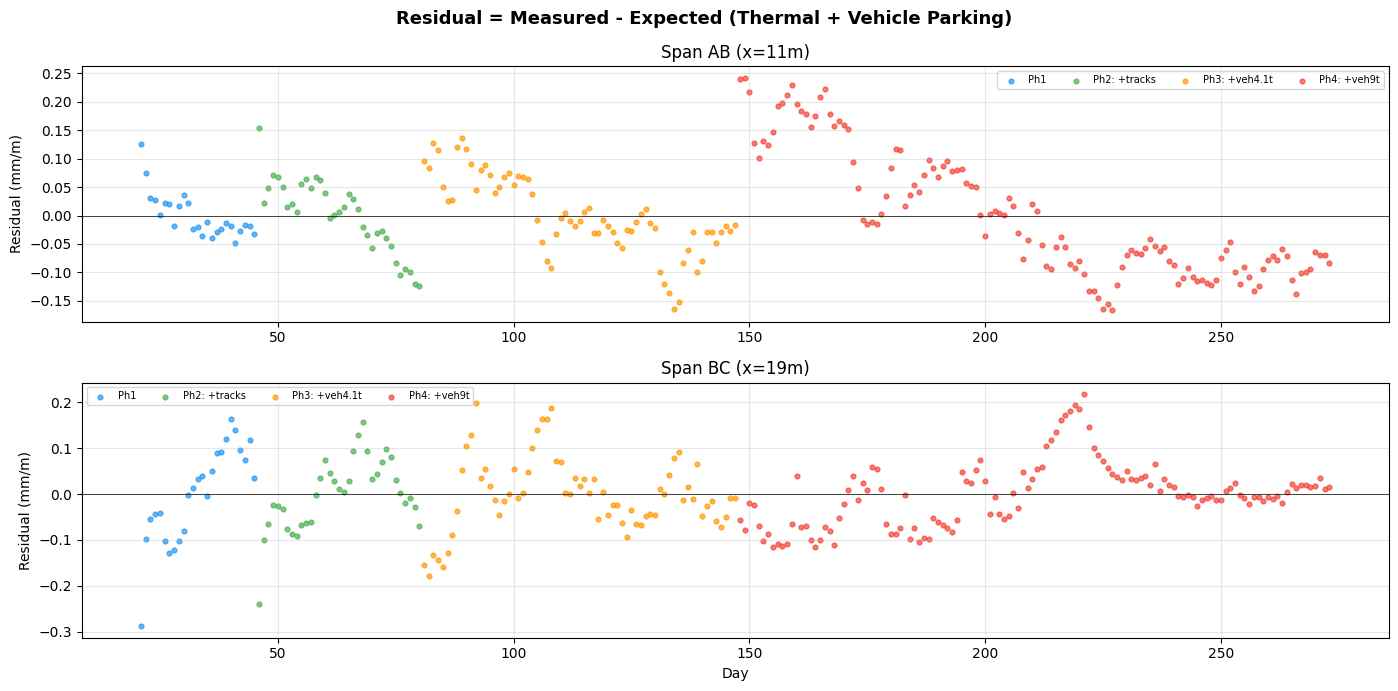

In [17]:
# ══════════════════════════════════════════════════════════════
# CELL 16: RESIDUAL ANALYSIS
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle('Residual = Measured - Expected (Thermal + Vehicle Parking)', fontsize=13, fontweight='bold')
for ax, res, title in [(axes[0], residual_11, 'Span AB (x=11m)'),
                        (axes[1], residual_19, 'Span BC (x=19m)')]:
    for ph in [1, 2, 3, 4]:
        mk = phases == ph
        ax.scatter(days[mk], res[mk], s=12, c=cp[ph], alpha=0.7, label=lp[ph])
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel('Residual (mm/m)'); ax.set_title(title)
    ax.legend(fontsize=7, ncol=4); ax.grid(True, alpha=0.3)
axes[1].set_xlabel('Day')
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'residual_analysis.png'), dpi=200)
plt.show()

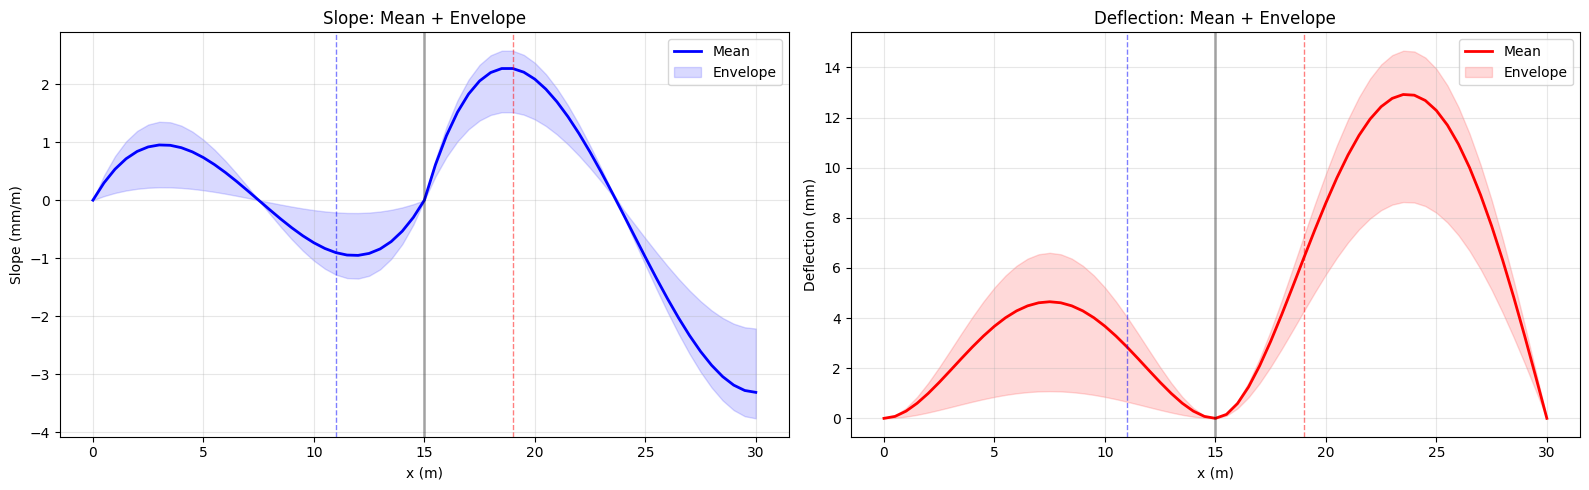

In [19]:
# ══════════════════════════════════════════════════════════════
# CELL 17: MEAN PROFILES WITH ENVELOPE
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(positions, fe_slopes.mean(0), 'b-', lw=2, label='Mean')
axes[0].fill_between(positions, fe_slopes.min(0), fe_slopes.max(0),
                     alpha=0.15, color='blue', label='Envelope')
axes[0].axvline(11, color='blue', ls='--', lw=1, alpha=0.5)
axes[0].axvline(19, color='red', ls='--', lw=1, alpha=0.5)
axes[0].axvline(15, color='k', lw=2, alpha=0.3)
axes[0].set_xlabel('x (m)'); axes[0].set_ylabel('Slope (mm/m)')
axes[0].set_title('Slope: Mean + Envelope'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(positions, fe_defls.mean(0), 'r-', lw=2, label='Mean')
axes[1].fill_between(positions, fe_defls.min(0), fe_defls.max(0),
                     alpha=0.15, color='red', label='Envelope')
axes[1].axvline(11, color='blue', ls='--', lw=1, alpha=0.5)
axes[1].axvline(19, color='red', ls='--', lw=1, alpha=0.5)
axes[1].axvline(15, color='k', lw=2, alpha=0.3)
axes[1].set_xlabel('x (m)'); axes[1].set_ylabel('Deflection (mm)')
axes[1].set_title('Deflection: Mean + Envelope'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'mean_envelope.png'), dpi=200)
plt.show()

**Discussion — Reconstructed Profiles:**

The mean slope profile shows the characteristic shape of a two-span continuous beam: zero at the fixed supports (x=0, x=15), with opposite signs in each half-span. The slope is zero at the points of maximum deflection (approximately x=7.5 and x=22.5 for uniform loading).

The deflection profile shows two humps — one per span — with the span BC deflection being larger than span AB. This asymmetry arises from the different support conditions: span AB is fixed-fixed (stiffer, less deflection) while span BC is fixed-pinned (less restrained at the pinned end, more deflection).

The envelope (min-max band) shows the range of variation across all 253 observations, capturing both load changes (phase transitions) and thermal effects.

In [18]:
# ══════════════════════════════════════════════════════════════
# CELL 18: SAVE RESULTS
# ══════════════════════════════════════════════════════════════

# Slopes CSV
df_slopes = pd.DataFrame()
df_slopes['day'] = days
df_slopes['phase'] = phases
df_slopes['tiltx_11m_meas'] = m11
df_slopes['tiltx_19m_meas'] = m19
df_slopes['net_udl_AB'] = net_AB
df_slopes['net_udl_BC'] = net_BC
df_slopes['expected_slope_11m'] = exp_11
df_slopes['expected_slope_19m'] = exp_19
df_slopes['residual_11m'] = residual_11
df_slopes['residual_19m'] = residual_19
for ip, xp in enumerate(positions):
    df_slopes[f'slope_{xp:.1f}m'] = fe_slopes[:, ip]
df_slopes.to_csv(os.path.join(OUT, 'reconstructed_slopes.csv'), index=False)

# Deflections CSV
df_defls = pd.DataFrame()
df_defls['day'] = days
df_defls['phase'] = phases
df_defls['net_udl_AB'] = net_AB
df_defls['net_udl_BC'] = net_BC
for ip, xp in enumerate(positions):
    df_defls[f'defl_{xp:.1f}m'] = fe_defls[:, ip]
df_defls.to_csv(os.path.join(OUT, 'reconstructed_deflections.csv'), index=False)

print(f'Saved to {OUT}/:')
print(f'  reconstructed_slopes.csv ({df_slopes.shape})')
print(f'  reconstructed_deflections.csv ({df_defls.shape})')
print(f'\nThese files serve as validation targets for the CEI-PCNN.')

Saved to C:\Users\ridoc\OneDrive\Desktop\Folders\SMACCs\Thesis\Physics Guided Framework\Draft\Models\outputs\processing\Tiltx\FEM/:
  reconstructed_slopes.csv ((253, 71))
  reconstructed_deflections.csv ((253, 65))

These files serve as validation targets for the CEI-PCNN.


---
## Summary

The FEM baseline successfully:

1. **Discovered 4 unknown load components** progressively across phases (tendon, tracks, vehicle 4.1t, additional weight)
2. **Reconstructed full-field slope and deflection** at 0.5m intervals for all 253 daily observations
3. **Validated at machine precision** — the forward reconstruction exactly matches the measured slopes at both sensor positions (error < 10⁻¹⁵ mm/m)
4. **Quantified thermal residuals** — the remaining day-to-day variation after removing dead loads represents thermal curvature effects

The reconstructed slopes and deflections are saved as CSV files and serve as the validation baseline for the CEI-PCNN in the next step.